In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import matplotlib.pyplot as plt


In [105]:
try:
    df=sns.load_dataset('planets')
    print('Dataset loaded Scuccesfully')
except:
    print('Dataset Not Found')

Dataset loaded Scuccesfully


In [106]:
df

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300000,7.10,77.40,2006
1,Radial Velocity,1,874.774000,2.21,56.95,2008
2,Radial Velocity,1,763.000000,2.60,19.84,2011
3,Radial Velocity,1,326.030000,19.40,110.62,2007
4,Radial Velocity,1,516.220000,10.50,119.47,2009
...,...,...,...,...,...,...
1030,Transit,1,3.941507,NaN,172.00,2006
1031,Transit,1,2.615864,NaN,148.00,2007
1032,Transit,1,3.191524,NaN,174.00,2007
1033,Transit,1,4.125083,NaN,293.00,2008


In [107]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
cat = ['method']
si = SimpleImputer(strategy='most_frequent')
for i in cat:
    df[i] = si.fit_transform(df[[i]]).ravel()

le = LabelEncoder()
for i in cat:
    df[i] = le.fit_transform(df[i])

In [108]:
df.isnull().sum().sort_values(ascending=False)

mass              522
distance          227
orbital_period     43
method              0
number              0
year                0
dtype: int64

In [109]:
df.select_dtypes(include=['int','float']).columns

Index(['method', 'number', 'orbital_period', 'mass', 'distance', 'year'], dtype='object')

In [110]:
px.box(df,x='year')

In [111]:
px.violin(df,x='distance')

In [112]:
px.box(df,x='orbital_period')

In [113]:
px.violin(df,x='number')

In [114]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.compose import ColumnTransformer,make_column_selector as select
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
num=Pipeline([
    ('imputer',KNNImputer(n_neighbors=5)),
    ('scaler',RobustScaler())
])


preprocessor=ColumnTransformer([
    ('preprocessing',num,select(dtype_include=['int','float']))
])
preprocessor

,transformers,"[('preprocessing', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,n_neighbors,5
,weights,'uniform'


In [115]:
X=df.drop('method',axis=1)
y=df['method']

from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
from xgboost import XGBRFClassifier

model=Pipeline([
    ('preprocessor',preprocessor),
    ('model',XGBRFClassifier(use_label_encoder=False))
])

param_grid={
    'model__n_estimators':[10,50,120],
    'model__max_depth':[5]
}
cv=GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    n_jobs=3,
    verbose=1,
    scoring='accuracy'
)

cv.fit(X_train,y_train)
y_pred=cv.predict(X_test)


Fitting 5 folds for each of 3 candidates, totalling 15 fits


In [116]:
from sklearn.metrics import accuracy_score,f1_score,r2_score,recall_score,confusion_matrix,classification_report
print("accuracy_score", accuracy_score(y_test, y_pred))
print("f1_score", f1_score(y_test, y_pred, average="weighted"))
print("recall_score", recall_score(y_test, y_pred, average="weighted"))
print("classification_report:\n", classification_report(y_test, y_pred))
print("confusion_matrix:\n", confusion_matrix(y_test, y_pred))

accuracy_score 0.9130434782608695
f1_score 0.9011070830386583
recall_score 0.9130434782608695
classification_report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       1.00      0.50      0.67         2
           2       0.60      0.38      0.46         8
           3       1.00      0.60      0.75         5
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         1
           7       0.92      0.95      0.93       120
           8       0.92      0.99      0.95        69

    accuracy                           0.91       207
   macro avg       0.55      0.43      0.47       207
weighted avg       0.90      0.91      0.90       207

confusion_matrix:
 [[  0   0   0   0   0   0   1   0]
 [  0   1   0   0   0   0   1   0]
 [  0   0   3   0   0   0   5   0]
 [  0   0   0   3   0   0   2   0]
 [  0   0   0   0   0   0   0   1]
 [  0   0   0   0   0   0   0   1]
 [

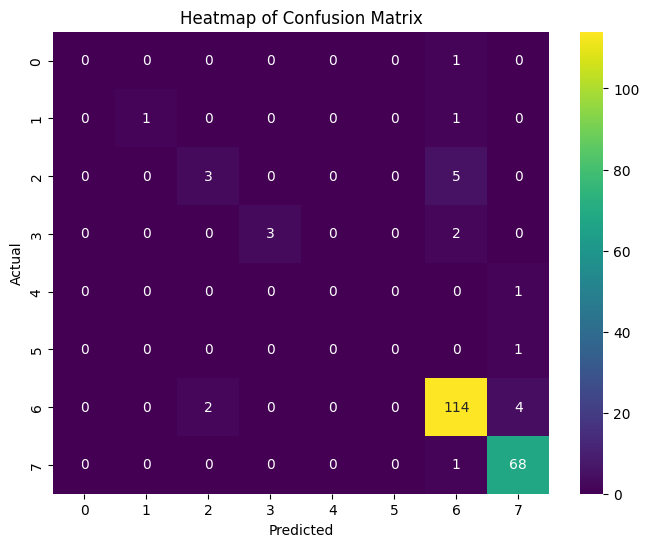

In [121]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cf = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cf, annot=True, cmap='viridis', fmt='d')

plt.title('Heatmap of Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()